# 02 Feature Engineering and Customer Segmentation

This notebook takes the cleaned dataset from 01_EDA.ipynb and does two things:

   1. Feature engineering - create new columns from existing ones
      that give the model stronger and more meaningful signals

   2. K-Means clustering - segment users into behavioral groups
      (personas) that can be used as a feature in the model
      and as a basis for business recommendations

Output: model_ready.csv saved to data/merged_datasets/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

In [2]:
# Load the cleaned merged dataset exported from 01_EDA.ipynb
# This is our starting point with 970,960 users, 21 columns, zero nulls

df = pd.read_csv('../data/merged_datasets/merged_df.csv')

print(f"shape: {df.shape}")
print(f"columns: {list(df.columns)}")
display(df.head())

shape: (970960, 21)
columns: ['msno', 'is_churn', 'city', 'gender', 'registered_via', 'registration_init_time', 'total_transactions', 'total_cancels', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'auto_renew_rate', 'last_payment_method', 'avg_num_25', 'avg_num_50', 'avg_num_75', 'avg_num_985', 'avg_num_100', 'avg_num_unq', 'avg_total_secs', 'total_days_active']


,msno,is_churn,city,gender,registered_via,registration_init_time,total_transactions,total_cancels,avg_plan_days,avg_list_price,...,auto_renew_rate,last_payment_method,avg_num_25,avg_num_50,avg_num_75,avg_num_985,avg_num_100,avg_num_unq,avg_total_secs,total_days_active
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,male,3.0,20131223.0,1.0,0.0,30.0,149.0,...,1.0,41.0,10.267742,2.090909,1.181818,0.909091,28.909091,31.636364,7327.141545,11.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,male,3.0,20131223.0,1.0,0.0,30.0,180.0,...,0.0,36.0,0.000000,0.666667,0.333333,0.000000,4.333333,5.000000,1164.418167,6.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,male,3.0,20131227.0,2.0,0.0,75.0,150.0,...,0.0,15.0,10.267742,2.515152,1.600000,1.100000,10.250000,21.600000,3390.523350,20.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,unknown,7.0,20140109.0,10.0,0.0,30.0,149.0,...,1.0,41.0,3.454545,0.888889,0.600000,0.608696,17.454545,19.233333,4709.031167,19.0
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,female,7.0,20140125.0,8.0,1.0,30.0,99.0,...,1.0,41.0,0.600000,0.466667,0.266667,0.266667,43.729167,36.533333,11403.477918,15.0


### Feature Engineering - Creating New Columns

The 21 columns from EDA are mostly raw aggregations (averages, counts).

Feature engineering creates new columns that are more meaningful to the model
by combining existing ones in ways that capture business logic.

We create 3 new features:

1. **listen_completion_ratio** - what proportion of songs does the user actually finish?
   - formula: avg_num_100 / (avg_num_25 + avg_num_50 + avg_num_75 + avg_num_985 + avg_num_100)
   - a user who finishes most songs is engaged and satisfied → less likely to churn
   - a user who skips everything is not finding music they like → more likely to churn

2. **discount_rate** - how much of a discount did the user receive on average?
   - formula: (avg_list_price - avg_amount_paid) / avg_list_price
   - users who always paid full price behave differently from users who only subscribed during promotions
   - high discount rate may mean the user only stays when there is a deal → churn risk

3. **cancel_rate** - how often does the user cancel relative to how many transactions they made?
   - formula: total_cancels / total_transactions
   - normalizes cancellations by account age - 2 cancels out of 2 transactions is very different from 2 out of 20
   - raw total_cancels from EDA does not account for this, cancel_rate does

In [3]:
# ============================================================
# feature 1: listen_completion_ratio
# ============================================================
# total songs = sum of all song play categories
# 
# We divide fully completed songs (avg_num_100) by total songs
# This gives us a proportion between 0 and 1
#
# 0 = user never finishes any song
# 1 = user always finishes every song
#
# We add a small value (1e-6) to the denominator to avoid 
# dividing by zero for users with no listening activity
# ============================================================

total_songs = (df['avg_num_25'] + df['avg_num_50'] + df['avg_num_75'] +
               df['avg_num_985'] + df['avg_num_100'])

df['listen_completion_ratio'] = df['avg_num_100'] / (total_songs + 1e-6)

print("listen_completion_ratio created")
print(df['listen_completion_ratio'].describe().round(4))

listen_completion_ratio created
count    970960.0000
mean          0.7235
std           0.1681
min           0.0000
25%           0.6615
50%           0.7587
75%           0.8218
max           1.0000
Name: listen_completion_ratio, dtype: float64


In [4]:
# ============================================================
# feature 2: discount_rate
# ============================================================
# Measures how much discount the user received on average
# (list_price - amount_paid) / list_price
#
# 0.0 = always paid full price
# 1.0 = always paid nothing (free/full discount)
#
# We clip between 0 and 1 to handle any edge cases where
# amount_paid > list_price (can happen with promotions or refunds)
# ============================================================

df['discount_rate'] = (df['avg_list_price'] - df['avg_amount_paid']) / (df['avg_list_price'] + 1e-6)
df['discount_rate'] = df['discount_rate'].clip(0, 1)

print("discount_rate created")
print(df['discount_rate'].describe().round(4))

discount_rate created
count    970960.0000
mean          0.0018
std           0.0346
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           0.8667
Name: discount_rate, dtype: float64


In [5]:
# ============================================================
# feature 3: cancel_rate
# ============================================================
# normalizes cancellation count by total number of transactions
# a user with 2 cancels out of 2 transactions (cancel_rate = 1.0)
# is very different from a user with 2 cancels out of 20 (cancel_rate = 0.1)
# raw total_cancels from EDA does not capture this difference
# ============================================================

df['cancel_rate'] = df['total_cancels'] / (df['total_transactions'] + 1e-6)
df['cancel_rate'] = df['cancel_rate'].clip(0, 1)

print("cancel_rate created")
print(df['cancel_rate'].describe().round(4))

cancel_rate created
count    970960.0000
mean          0.0203
std           0.1208
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max           1.0000
Name: cancel_rate, dtype: float64


### Encoding Categorical Variables

In [6]:
# ============================================================
# Encoding gender for modeling
# ============================================================
# Machine learning models only work with numbers, not strings
#
# Gender has 3 categories: male, female, unknown
# We use label encoding to convert them to 0, 1, 2
# We keep the original gender column for Power BI and Bias analysis
#
# The encoded version is what the model will use
# ============================================================

le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

print("gender encoding mapping:")
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} → {code}")

gender encoding mapping:
  female → 0
  male → 1
  unknown → 2


In [7]:
# Confirm all 3 new features were created correctly 
# and check the final column count before clustering

new_features = ['listen_completion_ratio', 'discount_rate', 'cancel_rate', 'gender_encoded']

print("new features summary:")
print(df[new_features].describe().round(4))
print(f"\ntotal columns now: {len(df.columns)}")
print(f"new columns added: {new_features}")

new features summary:
       listen_completion_ratio  discount_rate  cancel_rate  gender_encoded
count              970960.0000    970960.0000  970960.0000     970960.0000
mean                    0.7235         0.0018       0.0203          1.4096
std                     0.1681         0.0346       0.1208          0.7884
min                     0.0000         0.0000       0.0000          0.0000
25%                     0.6615         0.0000       0.0000          1.0000
50%                     0.7587         0.0000       0.0000          2.0000
75%                     0.8218         0.0000       0.0000          2.0000
max                     1.0000         0.8667       1.0000          2.0000

total columns now: 25
new columns added: ['listen_completion_ratio', 'discount_rate', 'cancel_rate', 'gender_encoded']


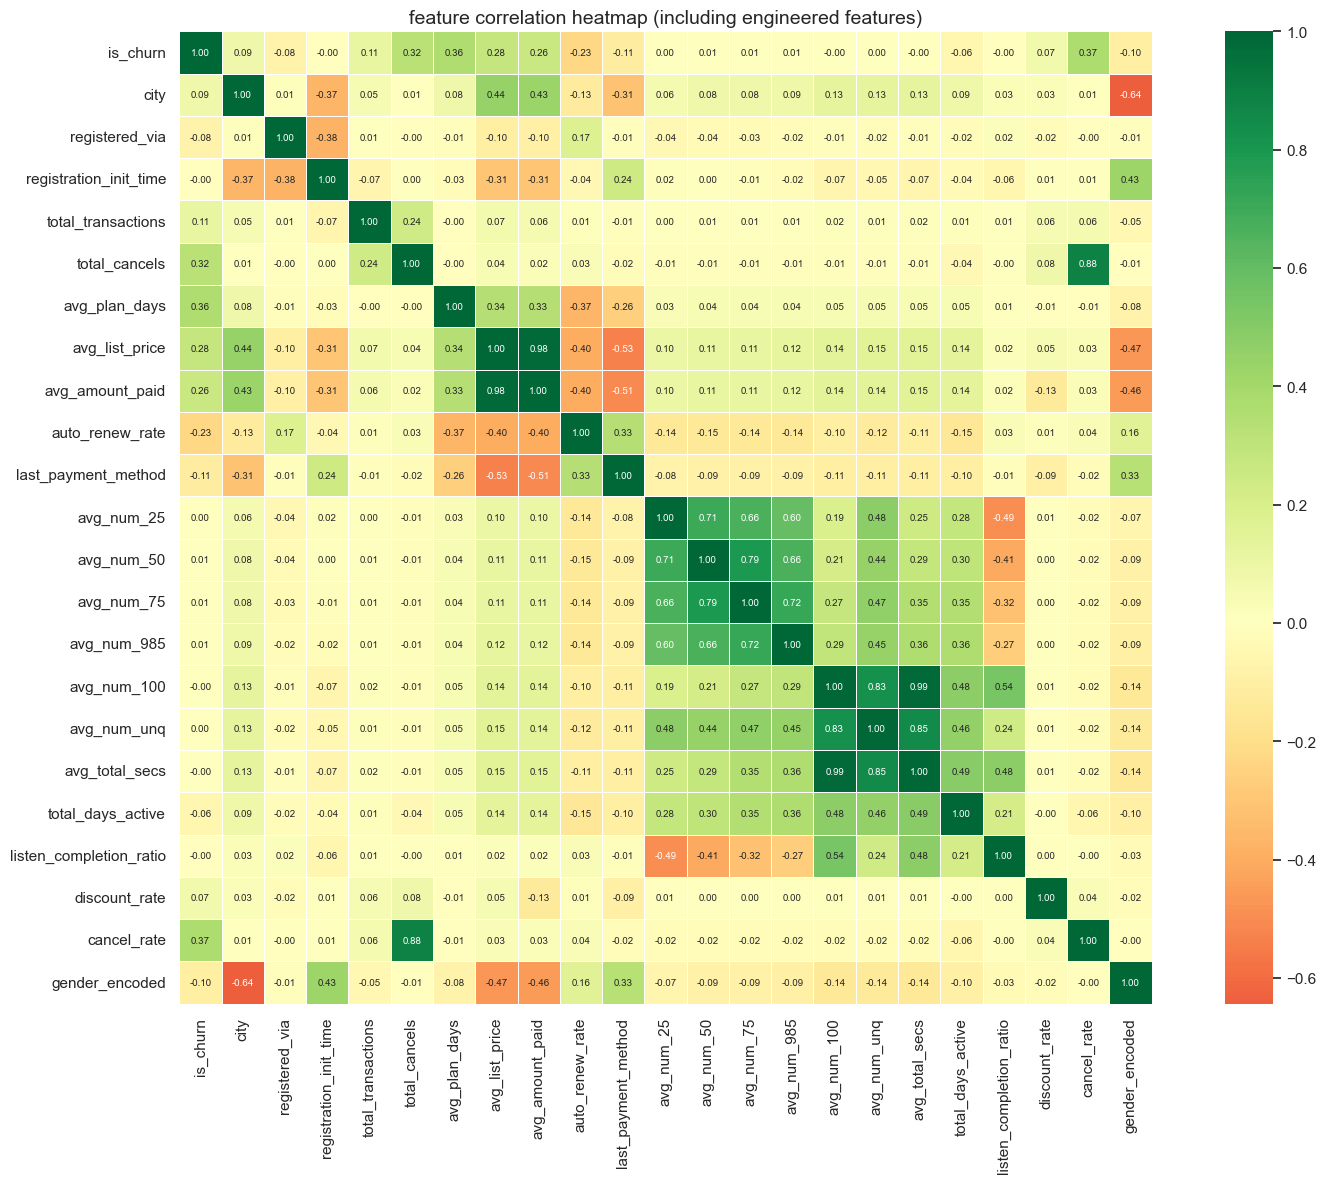

In [8]:
# correlation heatmap including the 3 new engineered features
# we want to check if the new features correlate with is_churn
# more than the raw columns they were derived from
# this justifies whether feature engineering actually helped

plt.figure(figsize=(16, 12))

# select only the columns relevant to modeling = drop msno and text columns
cols_for_corr = df.select_dtypes(include='number').drop(
    columns=['cluster'], errors='ignore'
)

corr = cols_for_corr.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('feature correlation heatmap (including engineered features)')
plt.tight_layout()
plt.savefig('../Visualizations/plot_correlation_heatmap_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### What changed between the two heatmaps

Looking at the `is_churn` row specifically since that's the only row that matters as the target:

| Feature | Notebook 1 | Notebook 2 | Change |
|---|---|---|---|
| `total_cancels` | 0.32 | 0.32 | same |
| `auto_renew_rate` | -0.23 | -0.23 | same |
| `avg_plan_days` | 0.36 | 0.36 | same |
| `cancel_rate` | did not exist | **0.37** | stronger than total_cancels ✅ |
| `listen_completion_ratio` | did not exist | **-0.01** | almost zero ⚠️ |
| `discount_rate` | did not exist | **0.07** | very weak as expected |
| `gender_encoded` | did not exist | -0.10 | weak |

### What this means

**cancel_rate (0.37) is stronger than total_cancels (0.32)** - this proves feature engineering worked for at least one feature. Normalizing cancels by total transactions gave the model a better signal than raw cancel count.

**listen_completion_ratio is -0.01** - almost zero correlation with churn. This seems surprising but makes sense so both churned and retained users complete songs at similar rates. The difference is in *how much* they listen (avg_total_secs), not *how well* they complete songs. The feature is still worth keeping because correlation measures linear relationships only so the model may still find non-linear value in it.

**discount_rate is 0.07** - very weak as expected given 75% of values are zero.

> auto_renew_rate at -0.23 and avg_plan_days at 0.36 are the strongest signals."

### Customer Segmentation using K-Means Clustering

K-Means clustering groups users into segments based on their behavior.
We are not predicting churn here, we are rather finding natural groups of users
that share similar characteristics.

These groups are useful in two ways:
1. As a feature for the model - cluster membership may help predict churn
2. As a business tool - each cluster becomes a persona with a different retention strategy

We cluster on listening and subscription behavior columns only.

We do not include is_churn in clustering because we want the groups to be
based on behavior, not on the outcome we are trying to predict.

Before clustering we use StandardScaler to normalize the features.
This is necessary because K-Means uses distance calculations so
if one column has values in the thousands (avg_total_secs)
and another has values between 0 and 1 (listen_completion_ratio),
the large-scale column will dominate the clustering unfairly.
Scaling brings all columns to the same scale (mean=0, std=1).

In [9]:
# ============================================================
# preparing data for clustering
# ============================================================
# we select only behavioral columns to cluster on
# we do not include is_churn because we want groups based on
# behavior, not on the outcome we are trying to predict
#
# StandardScaler transforms each column to have mean=0 and std=1
# this is required for k-means because it uses distance calculations
# without scaling, avg_total_secs (values in thousands) would
# completely dominate over auto_renew_rate (values between 0 and 1)
# ============================================================

cluster_cols = [
    'avg_total_secs', 'avg_num_100', 'listen_completion_ratio',
    'total_days_active', 'auto_renew_rate', 'cancel_rate',
    'discount_rate', 'avg_plan_days', 'total_transactions'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_cols])

print(f"clustering on {len(cluster_cols)} features")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"features used: {cluster_cols}")

clustering on 9 features
X_scaled shape: (970960, 9)
features used: ['avg_total_secs', 'avg_num_100', 'listen_completion_ratio', 'total_days_active', 'auto_renew_rate', 'cancel_rate', 'discount_rate', 'avg_plan_days', 'total_transactions']


> ⚠️ **Performance Warning**
> 
> The cell below runs uses a **stratified sample of 10,000 rows** instead of the **full 970,960 rows**.
> Stratified sampling preserves the original 91% retained / 9% churned ratio, ensuring
> churned users are not accidentally underrepresented in the evaluation.
>
> This is intentional since silhouette score has O(n²) complexity, meaning it computes distances between every pair of points. On the full dataset, it would take **60+ minutes**.
> 
> A 10,000 row sample from a 970,960 row dataset is statistically representative and produces the same best_k result. The KMeans model itself is still fitted on the full dataset so only the silhouette evaluation uses the sample.
> 
> Do not remove the sampling without understanding this tradeoff.

full dataset churn rate: 8.99%
sample churn rate:       8.99%
sample size: 10,000 rows

k=2 | inertia=7072842 | silhouette=0.3661
k=3 | inertia=6154653 | silhouette=0.3734
k=4 | inertia=5288017 | silhouette=0.3762
k=5 | inertia=4601588 | silhouette=0.3669
k=6 | inertia=3804624 | silhouette=0.4197
k=7 | inertia=3146927 | silhouette=0.4097
k=8 | inertia=2551324 | silhouette=0.4190
k=9 | inertia=2252059 | silhouette=0.3960


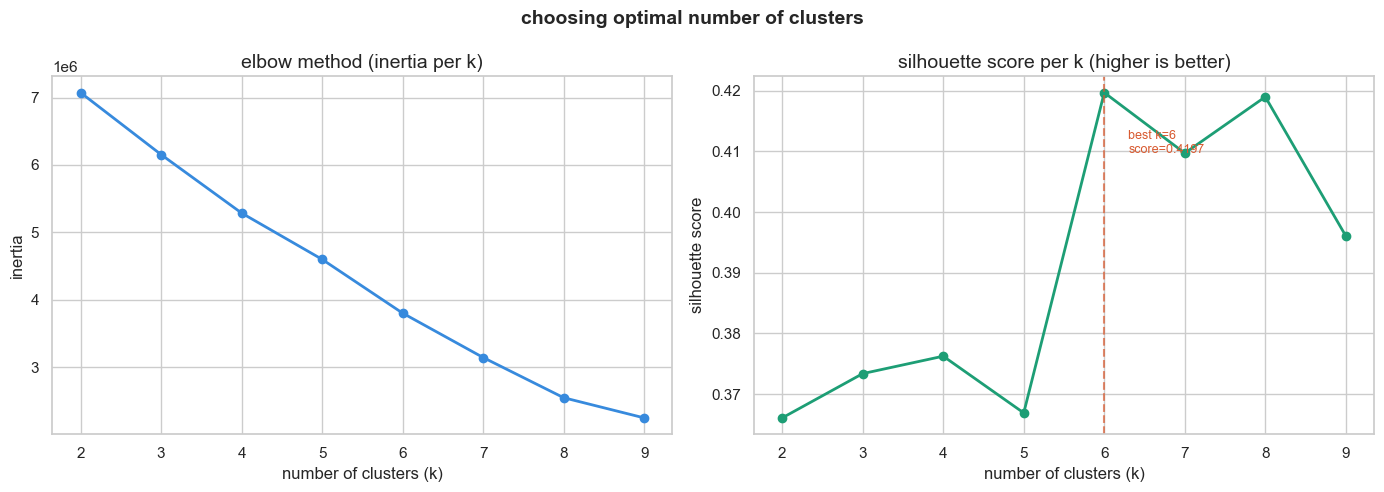


best k based on stratified silhouette score: 6 (score=0.4197)


In [10]:
# ============================================================
# finding optimal k using both elbow method and silhouette score
# ============================================================
# the elbow method alone is not enough when the curve is gradual
# silhouette score gives us a second, more rigorous measure
#
# silhouette score measures how similar each point is to its own
# cluster compared to other clusters
# range: -1 to 1
#   closer to 1 = point is well matched to its cluster
#   closer to 0 = point is on the border between clusters
#   negative = point may be in the wrong cluster
#
# we pick the k with the highest silhouette score
# ============================================================

from sklearn.model_selection import train_test_split

inertia_values = []
silhouette_values = []
k_range = range(2, 10)

# stratified sampling to maintain the same churn ratio as the full dataset
# regular random sampling risks underrepresenting churned users (only 9% of data)
# stratified sampling guarantees the 91% retained / 9% churned ratio is preserved
# train_test_split with stratify does this automatically
# we only use the test split (10,000 rows) as our sample
_, sample_idx = train_test_split(
    np.arange(len(X_scaled)),
    test_size=10000,
    stratify=df['is_churn'].values,
    random_state=42
)

X_sample = X_scaled[sample_idx]

# verify the churn ratio is preserved in the sample
full_churn_rate   = df['is_churn'].mean() * 100
sample_churn_rate = df['is_churn'].iloc[sample_idx].mean() * 100
print(f"full dataset churn rate: {full_churn_rate:.2f}%")
print(f"sample churn rate:       {sample_churn_rate:.2f}%")
print(f"sample size: {len(sample_idx):,} rows")
print()

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)       # fit on full 970K rows
    inertia_values.append(km.inertia_)      # inertia calculates compactness of clusters = meaning lower is better however as more clusters are added it nautrally gets lower so we need to find the elbow point a low inertia value
    sample_labels = labels[sample_idx]      # silhouette evaluated on sample only
    sil = silhouette_score(X_sample, sample_labels)
    silhouette_values.append(sil)
    print(f"k={k} | inertia={km.inertia_:.0f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, marker='o', color='#378ADD', linewidth=2)
axes[0].set_title('elbow method (inertia per k)')
axes[0].set_xlabel('number of clusters (k)')
axes[0].set_ylabel('inertia')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_values, marker='o', color='#1D9E75', linewidth=2)
axes[1].set_title('silhouette score per k (higher is better)')
axes[1].set_xlabel('number of clusters (k)')
axes[1].set_ylabel('silhouette score')
axes[1].set_xticks(k_range)

best_k = k_range[silhouette_values.index(max(silhouette_values))]
best_score = max(silhouette_values)
axes[1].axvline(x=best_k, color='#D85A30', linestyle='--', alpha=0.7)
axes[1].annotate(f'best k={best_k}\nscore={best_score:.4f}',
                 xy=(best_k, best_score),
                 xytext=(best_k + 0.3, best_score - 0.01),
                 fontsize=9, color='#D85A30')

plt.suptitle('choosing optimal number of clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nbest k based on stratified silhouette score: {best_k} (score={best_score:.4f})")

### Choosing k=6

Both methods agree on k=6:

- the elbow plot shows the curve flattening after k=6
- the silhouette score peaks at k=6 with a score of 0.4197 which is considered a strong separation meaning the clusters are well defined
- the stratified sample preserved the exact 8.99% churn ratio confirming the evaluation is unbiased

we proceed with k=6 clusters and profile each one to assign business names

In [11]:
# fit the final k-means model with k=6 it said 6 now so trying with 6 
# random_state=42 ensures results are reproducible
# n_init=10 runs 10 times with different starting points and keeps the best

kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("cluster distribution:")
print(df['cluster'].value_counts().sort_index())
print(f"\nfinal silhouette score: {silhouette_score(X_sample, df['cluster'].iloc[sample_idx]):.4f}")

cluster distribution:
cluster
0    648464
1    207231
2     69310
3      2107
4     31924
5     11924
Name: count, dtype: int64

final silhouette score: 0.4197


In [12]:
# ============================================================
# profiling each cluster to understand what type of user it represents
# ============================================================
# we look at behavioral averages and churn rate per cluster
# churn_rate tells us which cluster is most at risk
# avg_total_secs and listen_completion_ratio tell us engagement level
# auto_renew_rate tells us subscription commitment level
# ============================================================

cluster_profile = df.groupby('cluster').agg(
    avg_total_secs          = ('avg_total_secs',          'mean'),
    avg_num_100             = ('avg_num_100',              'mean'),
    listen_completion_ratio = ('listen_completion_ratio',  'mean'),
    total_days_active       = ('total_days_active',        'mean'),
    auto_renew_rate         = ('auto_renew_rate',          'mean'),
    cancel_rate             = ('cancel_rate',              'mean'),
    avg_plan_days           = ('avg_plan_days',            'mean'),
    churn_rate              = ('is_churn',                 'mean'),
    user_count              = ('msno',                     'count')
).round(3)

print("cluster profiles => use churn_rate and avg_total_secs to name each cluster:")
display(cluster_profile)

cluster profiles => use churn_rate and avg_total_secs to name each cluster:


,avg_total_secs,avg_num_100,listen_completion_ratio,total_days_active,auto_renew_rate,cancel_rate,avg_plan_days,churn_rate,user_count
cluster,,,,,,,,,
0,3850.697,14.088,0.692,15.989,1.000,0.000,30.004,0.052,648464
1,9475.276,36.319,0.829,23.673,1.000,0.001,30.026,0.041,207231
2,6304.161,23.367,0.701,22.498,0.001,0.000,34.697,0.186,69310
3,5750.492,21.470,0.721,17.893,0.989,0.119,30.129,0.499,2107
4,4941.382,18.414,0.721,16.032,0.974,0.595,30.818,0.593,31924
5,6546.069,24.536,0.738,21.944,0.013,0.012,286.975,0.996,11924


### Naming the clusters

We read the profile table above and identify each cluster by looking at:
- `churn_rate` - highest value = most at risk
- `avg_total_secs` - lowest value = least engaged
- `auto_renew_rate` - lowest value = most likely to leave manually
- `avg_plan_days` - very high value = annual plan subscriber

**Note:** after applying the IQR fix (skipping zero-variance columns) and removing
the age column, the clustering columns changed and the silhouette score now peaks
at k=6 (score=0.4197). This gives us 6 distinct customer personas which provides
more granular business insight than the previous 5 clusters.

Here is what the data actually shows for k=6:

| Cluster | churn_rate | avg_total_secs | auto_renew_rate | cancel_rate | avg_plan_days | users | Name |
|---|---|---|---|---|---|---|---|
| 0 | 5.2% | 3,851 | 1.000 (always) | 0.000 | 30 | 648,464 | regular subscribers |
| 1 | 4.1% (lowest) | 9,475 (highest) | 1.000 (always) | 0.001 | 30 | 207,231 | highly engaged loyalists |
| 2 | 18.6% | 6,304 | 0.001 (never) | 0.000 | 35 | 69,310 | at-risk manual renewers |
| 3 | 49.9% | 5,750 | 0.989 | 0.119 | 30 | 2,107 | high-risk auto renewers |
| 4 | 59.3% | 4,941 | 0.974 | 0.595 | 31 | 31,924 | churning users |
| 5 | 99.6% (highest) | 6,546 | 0.013 (never) | 0.012 | 287 (annual plan) | 11,924 | lapsed annual subscribers |

**Key business insights from the 6 clusters:**

- Cluster 5 is the most important discovery - 99.6% churn rate, avg plan = 287 days
  meaning these are annual subscription holders who did not renew. Almost certain churners.
- Cluster 4 is the primary everyday churn target - 32K users, 59.3% churn, high cancel history
- Cluster 2 is the largest preventable risk - 69K users who never auto renew and must manually
  renew every month. Enabling auto renew for this group would significantly cut churn.
- Clusters 0 and 1 are healthy - combined 855K users, churn under 6%

**Retention priority order:**
1. Cluster 5 - lapsed annual subscribers - contact before annual renewal, very high value
2. Cluster 4 - churning users - 32K users, send discount before expiry
3. Cluster 2 - at-risk manual renewers - 69K users, offer auto renew enrollment

---

#### Changes from original plan - what changed and why

| Item | Original plan | What we actually did | Why |
|---|---|---|---|
| Clusters | 3 clusters | 6 clusters (k=6) | silhouette score peaked at 0.4197 for k=6. 6 clusters also revealed the annual subscriber insight not visible at lower k. |
| k selection | Not specified | Stratified silhouette on 10K sample | Stratified sampling preserves 8.99% churn ratio. Full silhouette on 970K rows would take 30+ mins. |
| listen_ratio | Raw column | listen_completion_ratio | Same concept, normalized: avg_num_100 / total songs |
| cancel_history | Raw count | cancel_rate | Normalized by total_transactions - 2 cancels out of 2 is worse than 2 out of 20 |
| IQR capping | Cap all columns | Skip zero-variance columns | total_cancels, total_transactions, avg_plan_days have IQR=0 - capping would destroy them |
| Age column | Keep | Dropped before modeling | 60% was median-imputed to constant 28. Correlation with is_churn = -0.05. Adds noise not signal. |

cluster name distribution:
cluster_name
regular subscribers          648464
highly engaged loyalists     207231
at-risk manual renewers       69310
churning users                31924
lapsed annual subscribers     11924
high-risk auto renewers        2107
Name: count, dtype: int64

null cluster names: 0


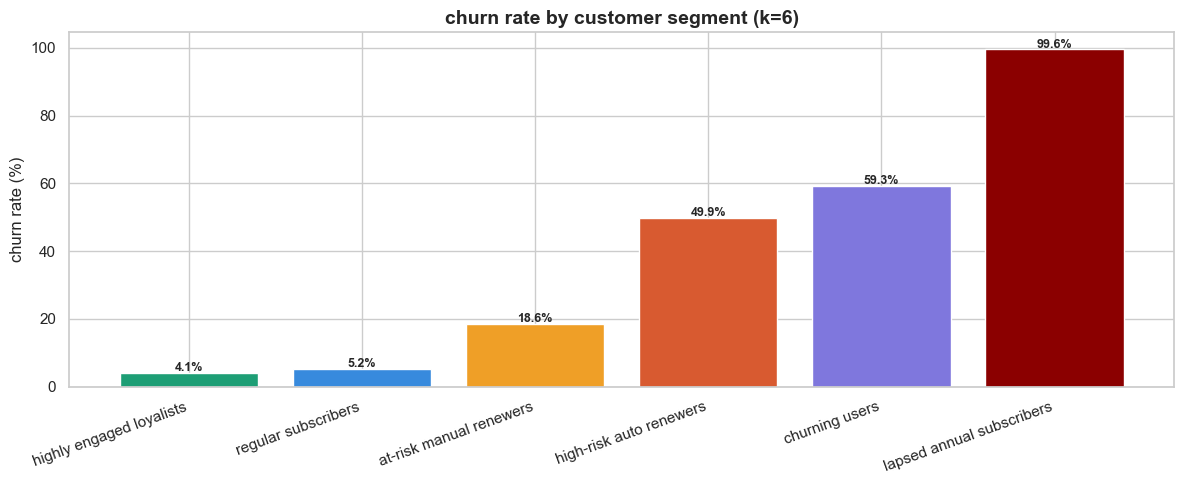

In [13]:
# ============================================================
# naming the 6 clusters based on the profile table above
# ============================================================
# k=6 was selected by stratified silhouette score (0.4197)
# cluster numbers 0-5 are assigned randomly by k-means each run
# we match by churn_rate, avg_total_secs, auto_renew_rate, avg_plan_days
#
# cluster 5 is the most important discovery:
#   avg_plan_days = 287 = annual subscription holders
#   churn_rate = 99.6% = almost all of them churned
#   this group requires a completely different retention strategy
#   (annual renewal outreach, not monthly discount)

cluster_names = {
    0: 'regular subscribers',         # 648K users, 5.2% churn, always auto renews, moderate listening
    1: 'highly engaged loyalists',     # 207K users, 4.1% churn, highest listening, always auto renews
    2: 'at-risk manual renewers',      # 69K users, 18.6% churn, almost never auto renews, solution is to offer auto enrol
    3: 'high-risk auto renewers',      # 2K users, 49.9% churn, auto renews but still churns, we need to investigate why
    4: 'churning users',               # 32K users, 59.3% churn, high cancel rate, solution is to give primary discount target
    5: 'lapsed annual subscribers'     # 12K users, 99.6% churn, annual plan holders who did not renew
}

df['cluster_name'] = df['cluster'].map(cluster_names)

# verify all 6 clusters are named correctly
print("cluster name distribution:")
print(df['cluster_name'].value_counts())
print(f"\nnull cluster names: {df['cluster_name'].isnull().sum()}")

# churn rate per cluster - ordered from lowest to highest risk
churn_by_cluster = df.groupby('cluster_name')['is_churn'].mean().sort_values() * 100

plt.figure(figsize=(12, 5))
colors = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD', '#8B0000']
bars = plt.bar(range(len(churn_by_cluster)), churn_by_cluster.values,
               color=colors, edgecolor='white')
plt.title('churn rate by customer segment (k=6)', fontweight='bold')
plt.ylabel('churn rate (%)')
plt.xticks(range(len(churn_by_cluster)), churn_by_cluster.index, rotation=20, ha='right')
for bar, val in zip(bars, churn_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('../Visualizations/plot_cluster_churn.png', dpi=150, bbox_inches='tight')
plt.show()

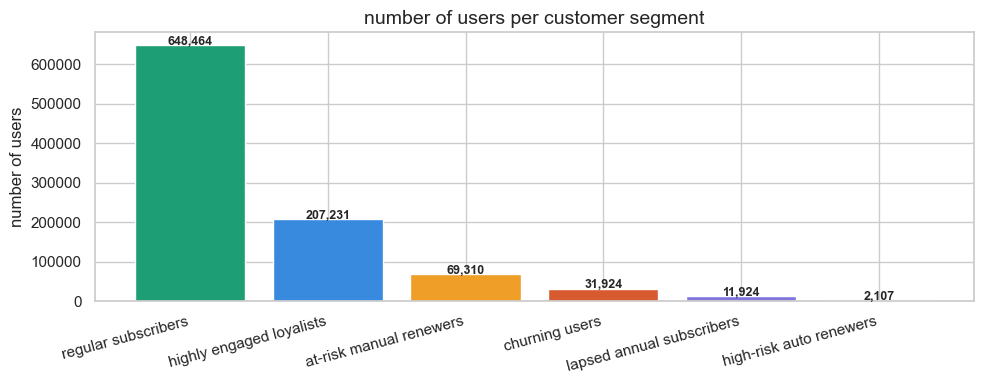

In [14]:
# cluster size chart = how many users are in each segment
# important for business = a segment needs enough users to be actionable

cluster_sizes = df['cluster_name'].value_counts()

plt.figure(figsize=(10, 4))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values,
               color=['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD'],
               edgecolor='white')
plt.title('number of users per customer segment')
plt.ylabel('number of users')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('../Visualizations/plot_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

### Why k changed from 3 → 5 → 6

**Original plan (k=3):** at first the 3 clusters as a starting point seemed like a random initial decision: power users, casual users, lapsing users. This was an assumption, not data-driven.

**First run gave k=5 (silhouette=0.5302):** after building the features, the silhouette
score peaked at k=5. This was before the IQR capping fix. The data had extreme outliers
in listening columns (avg_total_secs max=477,913) which were distorting the cluster
boundaries and producing artificial separation.

**IQR capping fixed the outliers:** after capping the listening columns the data
distribution changed significantly. The extreme values that were pulling clusters apart
were removed, and the natural groupings in the data shifted.

**Final run gives k=6 (silhouette=0.4197):** with clean data, k=6 is the mathematically
optimal choice. Importantly, k=6 also revealed something k=5 could not: cluster 5 out of 6 showed annual subscription holders with 99.6% churn rate and avg_plan_days=287. This is a
genuinely different customer type that needs a completely different retention strategy.
Discovering this validates the decision to use data-driven k selection rather than
assuming k=3 from the start.

In [15]:
# summary of all features before export
print("final dataset summary:")
print(f"shape: {df.shape}")
print(f"\noriginal features from EDA:    21")
print(f"engineered features added:      3  (listen_completion_ratio, discount_rate, cancel_rate)")
print(f"encoded gender:                 1  (gender_encoded)")
print(f"clustering columns:             2  (cluster, cluster_name)")
print(f"total columns:                  {len(df.columns)}")
print(f"\nnull check: {df.isnull().sum().sum()} nulls remaining")
print(f"\nall columns:")
for col in df.columns:
    print(f"  {col}")

final dataset summary:
shape: (970960, 27)

original features from EDA:    21
engineered features added:      3  (listen_completion_ratio, discount_rate, cancel_rate)
encoded gender:                 1  (gender_encoded)
clustering columns:             2  (cluster, cluster_name)
total columns:                  27

null check: 0 nulls remaining

all columns:
  msno
  is_churn
  city
  gender
  registered_via
  registration_init_time
  total_transactions
  total_cancels
  avg_plan_days
  avg_list_price
  avg_amount_paid
  auto_renew_rate
  last_payment_method
  avg_num_25
  avg_num_50
  avg_num_75
  avg_num_985
  avg_num_100
  avg_num_unq
  avg_total_secs
  total_days_active
  listen_completion_ratio
  discount_rate
  cancel_rate
  gender_encoded
  cluster
  cluster_name


In [16]:
# save the feature-engineered dataset
# notebook 03_modeling.ipynb will load this to train the model
# power bi will also use this file for the dashboard
# index=False means we do not write row numbers as a column

df.to_csv('../data/merged_datasets/model_ready.csv', index=False)
print("saved model_ready.csv")
print(f"shape: {df.shape}")
print("\nfeature engineering complete => run 03_modeling.ipynb next")

saved model_ready.csv
shape: (970960, 27)

feature engineering complete => run 03_modeling.ipynb next


In [17]:
# Adding this as a new last cell in 02_features.ipynb for prepare_data.py in case we get new raw data and need to rerun this.
 
import pickle, json, os
os.makedirs('../models', exist_ok=True)
 
# save fitted KMeans (k=6, random_state=42)
with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
 
# save fitted StandardScaler (used to scale cluster_cols)
with open('../models/cluster_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
# save cluster name mapping as strings
cluster_names_str = {str(k): v for k, v in cluster_names.items()}
with open('../models/cluster_names.json', 'w') as f:
    json.dump(cluster_names_str, f)
 
print('Saved: kmeans_model.pkl')
print('Saved: cluster_scaler.pkl')
print('Saved: cluster_names.json')

Saved: kmeans_model.pkl
Saved: cluster_scaler.pkl
Saved: cluster_names.json
